In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT
mpl.rc('text', usetex = True)

In [3]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(phase):
   tmp = phase.split('_')
   refl = "+"
   pol = tmp[1]
   wave = "S"
   m = "0"

   if (tmp[0] == 'b'):
       refl = "-"
   if (tmp[2] == '1'):
       wave = "P"
   if (tmp[3] == '1'):
       m = "1"
   elif (tmp[3] == 'm1'):
       m = "-1"

   return wave+"$^"+refl+"_{\\mathrm{" +pol + "}" + m + "}$"

In [4]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

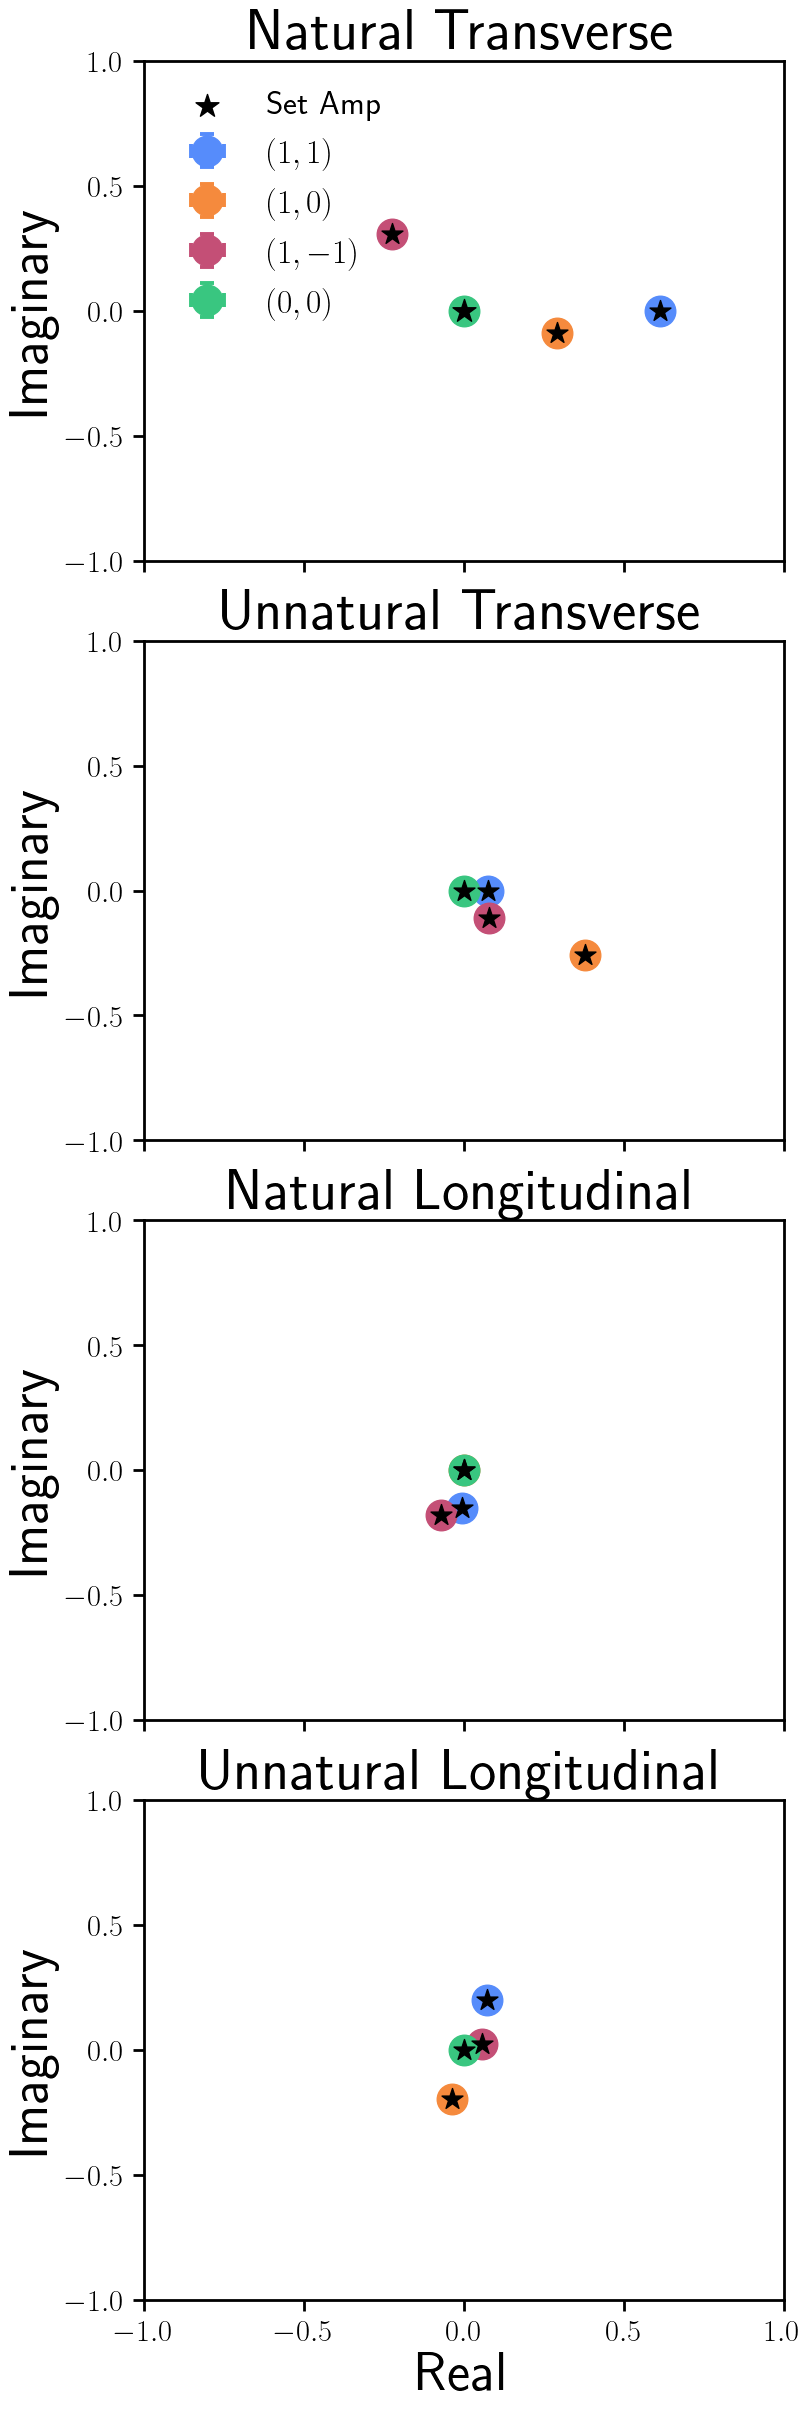

In [58]:
plt.rcParams.update({
    "font.size": 36,
    "axes.titlesize": 42,
    "axes.labelsize": 40,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 34,
    "lines.linewidth": 4.0,
    "axes.linewidth": 2.8,
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,
    "xtick.minor.size": 6,
    "ytick.minor.size": 6,
})

def apply_poster_axis_style(ax, labelsize=20):
    ax.tick_params(axis='both', which='major', labelsize=labelsize, width=2.0, length=8, pad=6)
    ax.tick_params(axis='both', which='minor', width=1.6, length=5)
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
# Initialise arrays for each wave
aT = np.empty(4)
bT = np.empty(4)
aL = np.empty(4)
bL = np.empty(4)

# DataFrame column names
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_0_0"]

tru_mags = np.array([0.8,0.4,0.5,0,
           0.1,0.6,0.18,0,
           0.2,0,0.25,0,
           0.28,0.26,0.08,0])

tru_mags = (tru_mags*np.sqrt(1/np.sum(np.square(tru_mags))))

tru_phases = [0, -0.3, 2.2, 0,
             0, -0.6, -0.95, 0,
             -1.6, 0, -1.95, 0,
             1.22, -1.76, 0.4, 0]

Q2 = np.array([1])

titles = ["Natural Transverse", "Unnatural Transverse", "Natural Longitudinal" ,"Unnatural Longitudinal"]
legends = ["$(1,1)$", "$(1,0)$", "$(1,-1)$", "$(0,0)$"]
N  = 903
# For HERMEs data they are saved this way (4 Q2 bins)
df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/fixedamps.root")
df = df.Filter("log_val<=-8")
arrays_mag = df.AsNumpy(columns=cols_mag)
arrays_phase = df.AsNumpy(columns=cols_phase)

fig, axs = plt.subplots(4, 1, figsize=(8, 24), sharex=True, constrained_layout=True)
for j in range(4):
    #The main plotting
    for k in range(4):
        mag = arrays_mag[cols_mag[k + 4*j]]
        phase = arrays_phase[cols_phase[k + 4*j]]

        tru_mag = tru_mags[k + 4*j]
        tru_phase = tru_phases[k + 4*j]

        re = mag*np.cos(phase)
        im = mag*np.sin(phase)

        tru_re = tru_mag*np.cos(tru_phase)
        tru_im = tru_mag*np.sin(tru_phase)

        mean_mag = np.mean(mag)
        err_mag = np.std(mag)

        mean_phase = circular_mean(phase)
        if (cols_mag[k + 4*j] == "a_L_1_0" or k==3):
            mean_phase = 0
        err_phase= circular_std(phase)

        mean_re = np.mean(re)
        err_re= np.std(re)

        mean_im = np.mean(im)
        err_im = np.std(im)

        # axs[j,0].errorbar(mean_phase,mean_mag,xerr = err_phase,yerr = err_mag, fmt='.', markersize=14, elinewidth=2)
        # axs[j,0].axis(xmin=-np.pi, xmax = np.pi, ymin = -0.05, ymax = 1)
        # axs[j,0].scatter(tru_phase, tru_mag, zorder=5, marker="*", color="black")


        if j==0:
            axs[j].errorbar(mean_re,mean_im,xerr = err_re,yerr = err_im,fmt='o', markersize=22, elinewidth=3.2,
                    capsize=5, capthick=2.8,
                    label=legends[k]
                )
            if k==3:
                axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", color="black", s=300, label="Set Amp")
            else:
                axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", s=250, color="black")
        else:
            axs[j].errorbar(mean_re,mean_im,xerr = err_re,yerr = err_im,fmt='o', markersize=22, elinewidth=3.2,
                    capsize=5, capthick=2.8,
                    label=legends[k]
                )
            axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", s=250, color="black")
        axs[j].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)

        # axs[j,0].set_ylabel("Magnitude")
        axs[j].set_ylabel("Imaginary")
        if (j==3):
            # axs[j,0].set_xlabel("Phase")
            axs[j].set_xlabel("Real")

        axs[j].set_title(titles[j])
        axs[j].set_yticks([-1,-0.5,0,0.5,1])
        axs[j].set_xticks([-1,-0.5,0,0.5,1])

        apply_poster_axis_style(axs[j], labelsize=22)

    axs[0].legend(loc="upper left", frameon=False, fontsize=24)

    # Maybe have an overall title giving more information?
    #fig.tight_layout()
    fig.savefig("fixed_amps.pdf", dpi=600,bbox_inches='tight',transparent=True, format= 'pdf')

In [ ]:
ticks = np.arange(-1, 1.5, 0.5)
print(ticks)

fig = plt.figure(figsize=(8,8))
axs = fig.subplots(2,2, sharex=True, sharey=True).flatten()
for j in range(4):
    #The main plotting
    for k in range(4):
        mag = arrays_mag[cols_mag[k + 4*j]]
        phase = arrays_phase[cols_phase[k + 4*j]]

        tru_mag = tru_mags[k + 4*j]
        tru_phase = tru_phases[k + 4*j]

        re = mag*np.cos(phase)
        im = mag*np.sin(phase)

        tru_re = tru_mag*np.cos(tru_phase)
        tru_im = tru_mag*np.sin(tru_phase)

        mean_re = np.mean(re)
        err_re= np.std(re)

        mean_im = np.mean(im)
        err_im = np.std(im)

        axs[j].errorbar(mean_re,mean_im,xerr = err_re,yerr = err_im, fmt='.', markersize=14, elinewidth=2, label=ToWave(cols_mag[k + 4*j]))
        if k==0:
            if j == 0:
                axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", color="black", label="Fixed Value")
            axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", color="black")
        axs[j].scatter(tru_re, tru_im, zorder=5, marker="*", color="black")
        axs[j].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)
        axs[j].set_xticks(ticks)
        axs[j].set_yticks(ticks)

        axs[j].legend()
    # Maybe have an overall title giving more information?
    axs[2].set_title("Longitudinal Natural Amplitudes")
    axs[3].set_title("Longitudinal Unnatural Amplitudes")
    axs[0].set_title("Transverese Natural Amplitudes")
    axs[1].set_title("Transverse Unnatural Amplitudes")
    fig.supylabel("$\\Im$", size=16)
    fig.supxlabel("$\\Re$", size=16)

    fig.tight_layout()
    fig.savefig("fixed_amps_publ.pdf", transparent=True, dpi=800, format= 'pdf')